In [4]:
import pandas as pd
from sqlalchemy import create_engine
from utils.database import get_engine
import seaborn as sns
import matplotlib.pyplot as plt

engine = get_engine()

In [6]:
df_logistics = pd.read_sql(
    "SELECT * FROM vw_logistics_analysis",
    engine
)

df_logistics.head()

,sku,transportation_modes,shipping_carriers,routes,shipping_costs,costs
0,SKU0,Road,Carrier B,Route B,2.956572,187.752075
1,SKU1,Road,Carrier A,Route B,9.716575,503.065579
2,SKU2,Air,Carrier B,Route C,8.054479,141.920282
3,SKU3,Rail,Carrier C,Route A,1.729569,254.776159
4,SKU4,Air,Carrier A,Route A,3.890548,923.440632


In [8]:
print(df_logistics.info())
print(df_logistics.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   sku                   100 non-null    object 
 1   transportation_modes  100 non-null    object 
 2   shipping_carriers     100 non-null    object 
 3   routes                100 non-null    object 
 4   shipping_costs        100 non-null    float64
 5   costs                 100 non-null    float64
dtypes: float64(2), object(4)
memory usage: 4.8+ KB
None
Index(['sku', 'transportation_modes', 'shipping_carriers', 'routes',
       'shipping_costs', 'costs'],
      dtype='object')


In [9]:
df_logistics.describe()

,shipping_costs,costs
count,100.000000,100.000000
mean,5.548149,529.245782
std,2.651376,258.301696
min,1.013487,103.916248
25%,3.540248,318.778455
50%,5.320534,520.430444
75%,7.601695,763.078231
max,9.929816,997.413450


In [11]:
# Total Shipping Cost by Mode
transport_cost = (
    df_logistics
    .groupby("transportation_modes")["shipping_costs"]
    .sum()
    .sort_values(ascending=False)
)

transport_cost

transportation_modes
Road    160.721346
Air     156.463824
Rail    153.134742
Sea      84.494995
Name: shipping_costs, dtype: float64

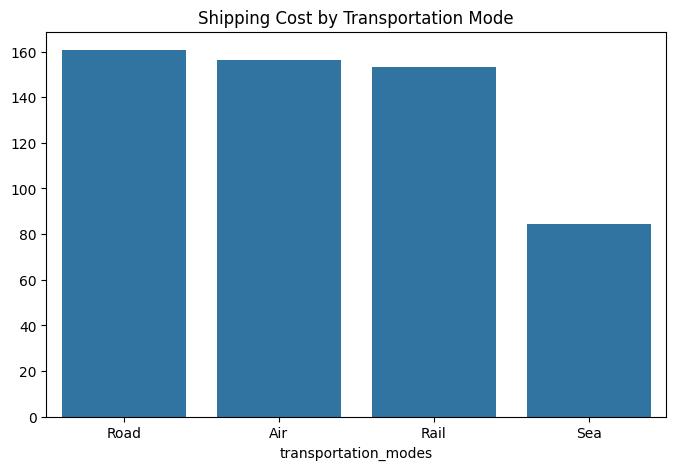

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=transport_cost.index,
    y=transport_cost.values
)

plt.title("Shipping Cost by Transportation Mode")

plt.show()

### Transportation Mode Analysis

Road transportation generated the highest total shipping cost, followed closely by Air and Rail transport. Sea transportation contributed the lowest shipping cost among all transportation modes.

The relatively balanced costs across Road, Air, and Rail suggest that transportation expenses are distributed across multiple logistics channels rather than concentrated in a single mode.

In [13]:
# Cost by Carrier
carrier_cost = (
    df_logistics
    .groupby("shipping_carriers")["shipping_costs"]
    .sum()
    .sort_values(ascending=False)
)

carrier_cost

shipping_carriers
Carrier B    236.897620
Carrier C    162.379457
Carrier A    155.537831
Name: shipping_costs, dtype: float64

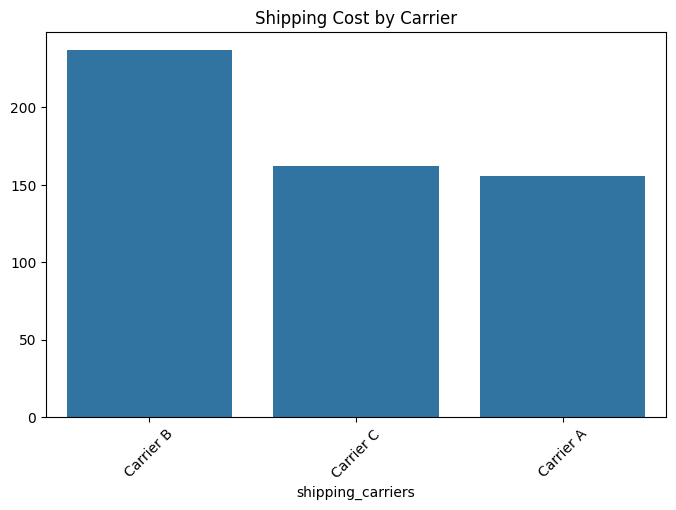

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=carrier_cost.index,
    y=carrier_cost.values
)

plt.title("Shipping Cost by Carrier")

plt.xticks(rotation=45)

plt.show()

### Shipping Carrier Analysis

Carrier B accounts for the highest total shipping cost among all carriers. This may indicate higher shipment volumes, more expensive routes, or greater reliance on this carrier.

Further investigation could determine whether the higher cost is justified by operational performance or service quality.

In [15]:
# Route Cost
route_cost = (
    df_logistics
    .groupby("routes")["shipping_costs"]
    .sum()
    .sort_values(ascending=False)
)

route_cost

routes
Route A    231.327064
Route B    205.423475
Route C    118.064369
Name: shipping_costs, dtype: float64

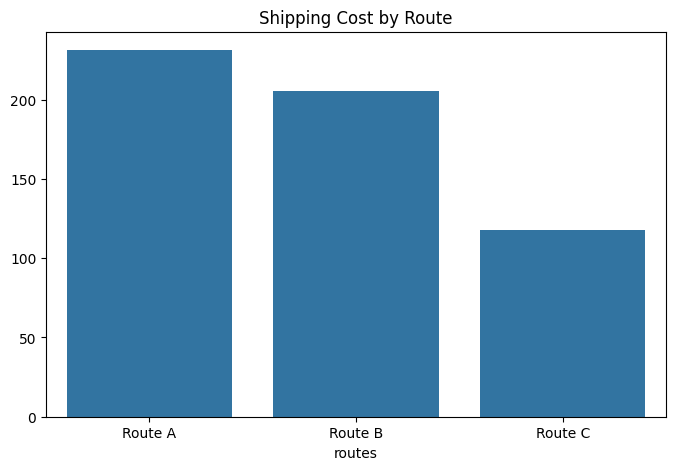

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=route_cost.index,
    y=route_cost.values
)

plt.title("Shipping Cost by Route")

plt.show()

### Route Analysis

Route A generated the highest shipping cost, followed by Route B. Route C contributed significantly lower logistics expenses.

Route-level cost analysis helps identify transportation corridors that may benefit from optimization initiatives.

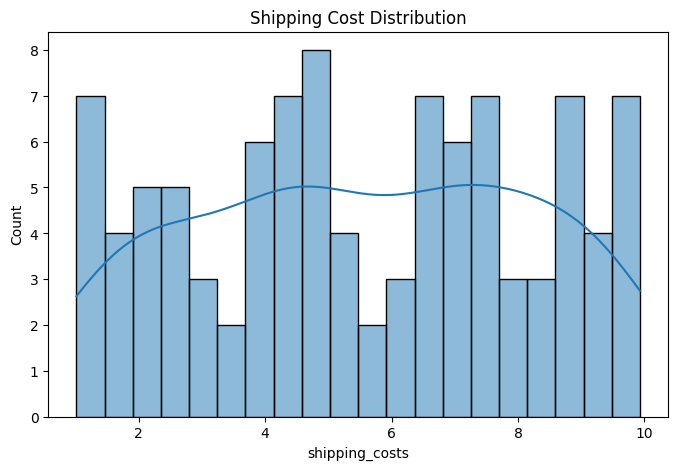

In [17]:
# Shipping cost disribution
plt.figure(figsize=(8,5))

sns.histplot(
    df_logistics["shipping_costs"],
    bins=20,
    kde=True
)

plt.title("Shipping Cost Distribution")

plt.show()

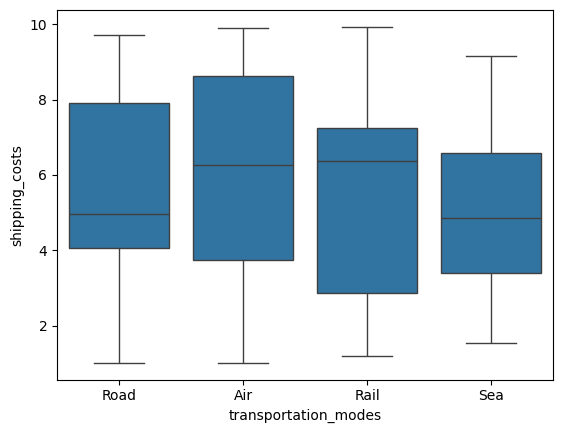

In [18]:
sns.boxplot(
    data=df_logistics,
    x="transportation_modes",
    y="shipping_costs"
)

plt.show()

### Shipping Cost Distribution

The shipping cost distribution does not follow a normal pattern and exhibits multiple peaks, indicating a multimodal distribution.

This suggests that shipping costs may be influenced by underlying operational groups such as transportation modes, carriers, or routes. Further segmentation of logistics costs can provide deeper insight into cost drivers across the supply chain network.